# Sentinel-2 评估结果 IEEE 风格总览图

这个 notebook 会读取 `data/output/evaluation_results_sentinel.csv`，并生成一张更适合论文/汇报的 **IEEE 风格复合图**：

- 四个核心指标（RMSE / MAE / R / Outlier Ratio）的 **grouped bar chart**；
- 柱高表示各 band 上的**中位数**，误差棒表示 **IQR（Q1–Q3）**；
- 右侧附带 **平均名次热力图** 与 **获胜次数统计图**；
- 同时导出为 **PNG / PDF / SVG**，方便直接插入论文、海报或汇报 PPT。

Loaded 324 rows from: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/output/evaluation_results_sentinel.csv
Scenes per band per algorithm: 18


,Image,Algorithm,RMSE,MAE,R,OutlierRatio,Band
0,COPERNICUS_S2_HARMONIZED_B2_lon100.1120_lat25....,NuFrost,274.929786,88.264128,0.647861,0.003360,B2
1,COPERNICUS_S2_HARMONIZED_B2_lon100.1120_lat25....,NuFrost,104.418258,68.309744,0.945044,0.005340,B2
2,COPERNICUS_S2_HARMONIZED_B2_lon100.1120_lat25....,NuFrost,80.798894,54.476088,0.765247,0.000040,B2
3,COPERNICUS_S2_HARMONIZED_B2_lon100.1120_lat25....,NuFrost,75.924699,57.809438,0.356387,0.004994,B2
4,COPERNICUS_S2_HARMONIZED_B2_lon100.7173_lat22....,NuFrost,67.544685,51.626720,0.766366,0.002180,B2


RMSE      MAE      R  OutlierRatio
Band Algorithm                                       
B2   NuFrost    130.121   80.612  0.717         0.005
     Zhu2015    312.269   97.260  0.325         0.010
     HANTS      393.988  213.219  0.579         0.076
B3   NuFrost    110.150   74.429  0.797         0.004
     Zhu2015    272.639   82.948  0.523         0.010
     HANTS      425.162  211.201  0.568         0.069
B4   NuFrost    146.944   88.283  0.827         0.005
     Zhu2015    576.616   97.754  0.433         0.013
     HANTS      601.342  281.901  0.608         0.092
B8   NuFrost    382.488  200.332  0.872         0.000
     Zhu2015    699.547  182.762  0.664         0.003
     HANTS      815.305  508.679  0.727         0.029
B11  NuFrost    199.146  129.623  0.951         0.001
     Zhu2015    488.687  112.364  0.736         0.004
     HANTS      423.028  287.782  0.855         0.022
B12  NuFrost    147.543   82.777  0.945         0.005
     Zhu2015    407.148   82.749  0.778         0.009
     HANTS      410.276  225.245  0.814         0.040

Algorithm,NuFrost,Zhu2015,HANTS
Metric,,,
RMSE ↓,1.0,2.17,2.83
MAE ↓,1.5,1.50,3.00
R ↑,1.0,3.00,2.00
Outlier ↓,1.0,2.00,3.00


Algorithm,NuFrost,Zhu2015,HANTS
Metric,,,
RMSE ↓,6,0,0
MAE ↓,3,3,0
R ↑,6,0,0
Outlier ↓,6,0,0


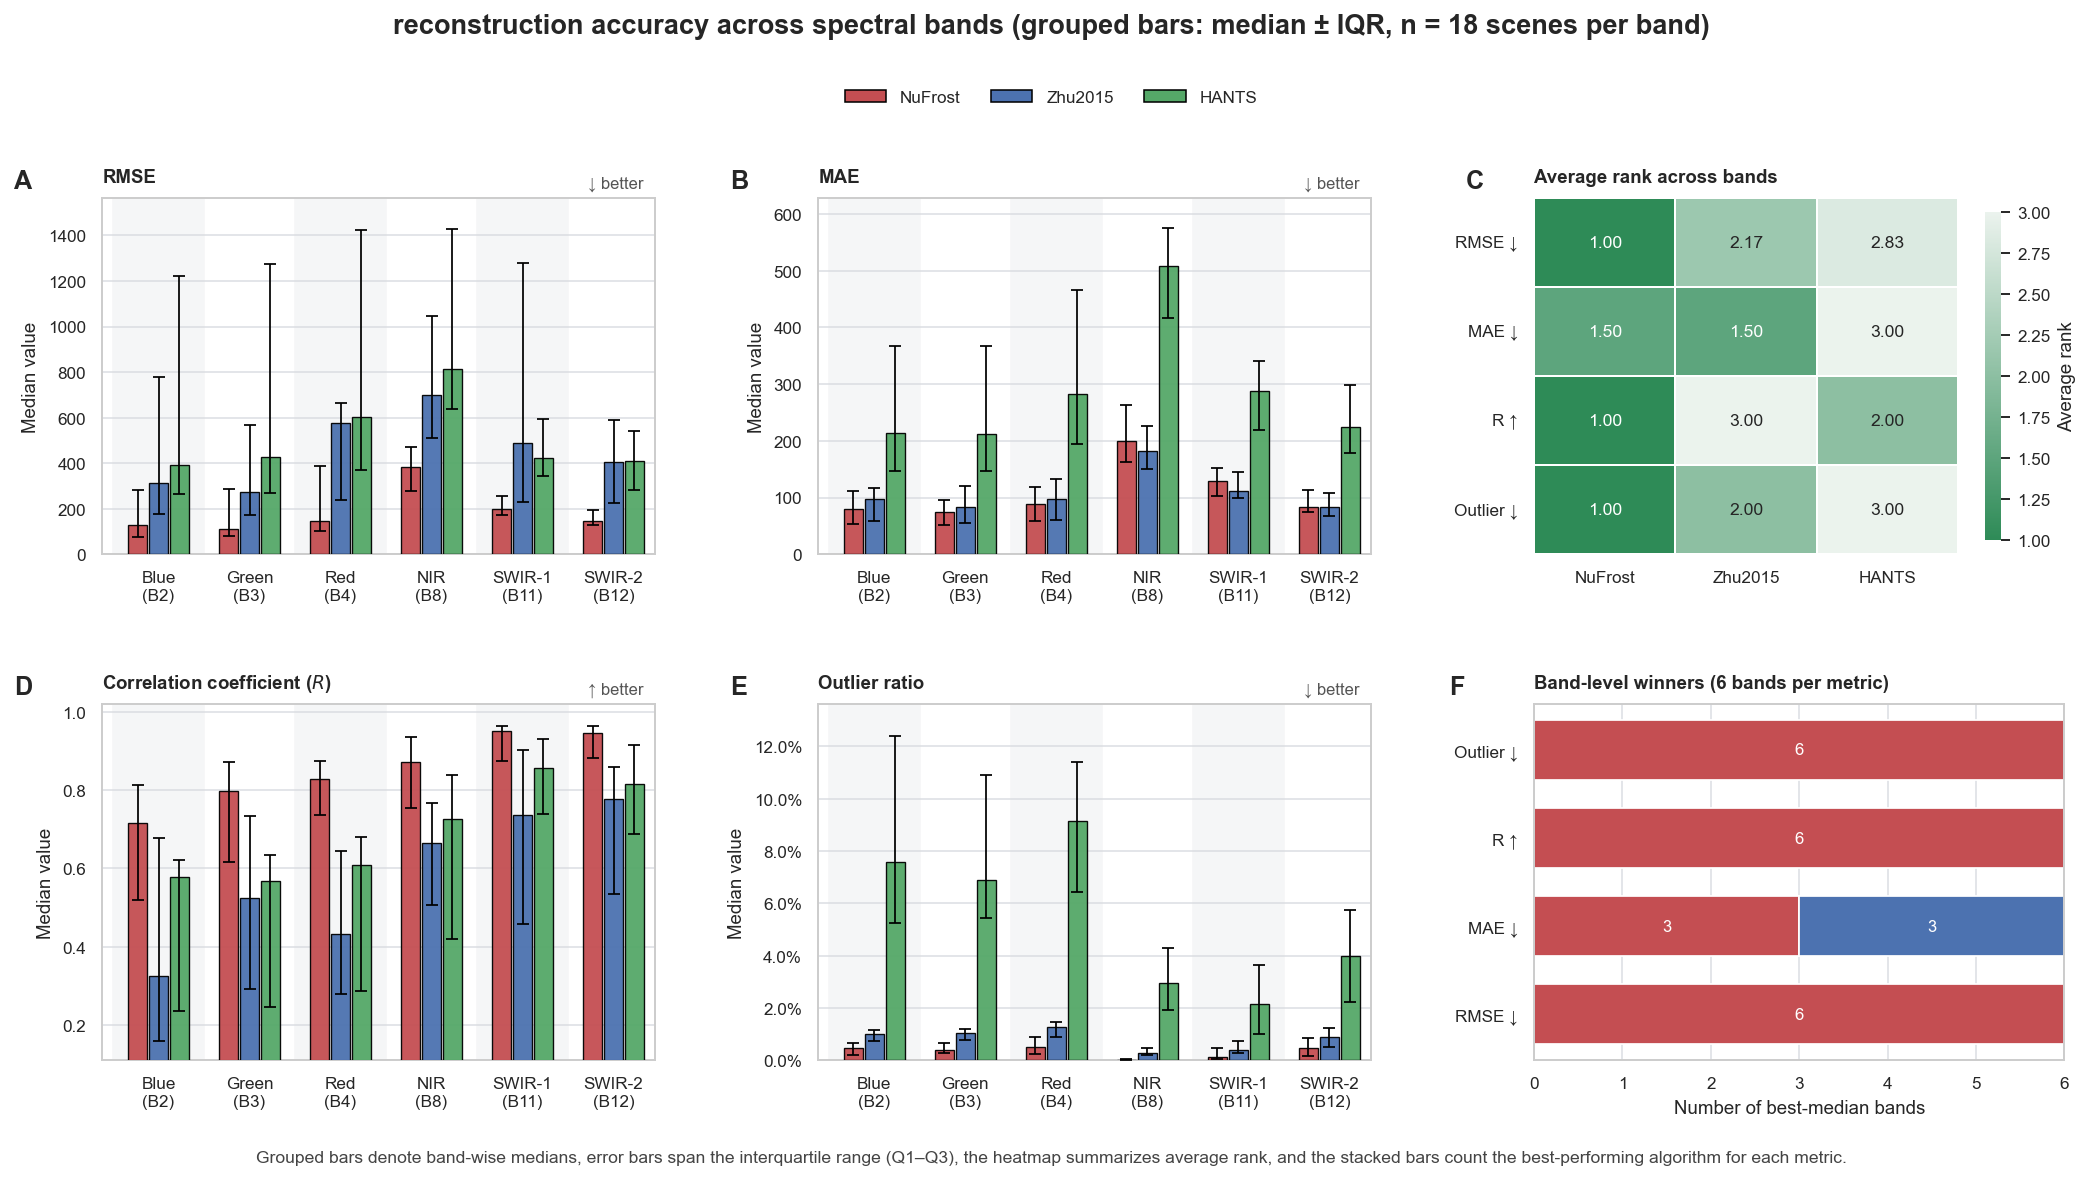

Saved PNG : /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/output/figures/sentinel_ieee_overview.png
Saved PDF : /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/output/figures/sentinel_ieee_overview.pdf
Saved SVG : /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/output/figures/sentinel_ieee_overview.svg


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from IPython.display import display
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATH = PROJECT_DIR / "data" / "output" / "evaluation_results_sentinel.csv"
FIG_DIR = PROJECT_DIR / "data" / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Cannot find CSV file: {CSV_PATH}")

band_order = ["B2", "B3", "B4", "B8", "B11", "B12"]
band_labels = {
    "B2": "Blue\n(B2)",
    "B3": "Green\n(B3)",
    "B4": "Red\n(B4)",
    "B8": "NIR\n(B8)",
    "B11": "SWIR-1\n(B11)",
    "B12": "SWIR-2\n(B12)",
}
algo_order = ["NuFrost", "Zhu2015", "HANTS"]
palette = {
    "NuFrost": "#C44E52",
    "Zhu2015": "#4C72B0",
    "HANTS": "#55A868",
}
hatches = {
    "NuFrost": "",
    "Zhu2015": "",
    "HANTS": "",
}
metric_order = ["RMSE", "MAE", "R", "OutlierRatio"]
metric_titles = {
    "RMSE": "RMSE",
    "MAE": "MAE",
    "R": "Correlation coefficient ($R$)",
    "OutlierRatio": "Outlier ratio",
}
metric_directions = {
    "RMSE": "lower",
    "MAE": "lower",
    "R": "higher",
    "OutlierRatio": "lower",
}
metric_labels = {
    "RMSE": "RMSE ↓",
    "MAE": "MAE ↓",
    "R": "R ↑",
    "OutlierRatio": "Outlier ↓",
}

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "grid.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
sns.set_theme(style="whitegrid", context="paper")

df = pd.read_csv(CSV_PATH)
df["Band"] = df["Image"].str.extract(r"_(B\d{1,2})_lon")
df["Algorithm"] = pd.Categorical(df["Algorithm"], categories=algo_order, ordered=True)
df["Band"] = pd.Categorical(df["Band"], categories=band_order, ordered=True)
df = df.dropna(subset=["Band"]).sort_values(["Band", "Algorithm", "Image"]).reset_index(drop=True)

scene_count = int(df.groupby(["Band", "Algorithm"]).size().median())
print(f"Loaded {len(df)} rows from: {CSV_PATH}")
print(f"Scenes per band per algorithm: {scene_count}")
display(df.head())

median_overview = (
    df.groupby(["Band", "Algorithm"])[metric_order]
      .median()
      .reindex(pd.MultiIndex.from_product([band_order, algo_order], names=["Band", "Algorithm"]))
      .round(3)
)
display(median_overview)

def summarise_metric(metric: str) -> pd.DataFrame:
    return (
        df.groupby(["Band", "Algorithm"])[metric]
          .agg(
              median="median",
              q1=lambda s: s.quantile(0.25),
              q3=lambda s: s.quantile(0.75),
          )
          .reset_index()
          .assign(Metric=metric)
    )

summary_long = pd.concat([summarise_metric(metric) for metric in metric_order], ignore_index=True)

rank_records = []
win_records = []
for metric in metric_order:
    mat = (
        summary_long.query("Metric == @metric")
        .pivot(index="Band", columns="Algorithm", values="median")
        .reindex(band_order)
        .reindex(columns=algo_order)
    )
    ranks = mat.rank(axis=1, ascending=(metric_directions[metric] == "lower"), method="min")
    for algorithm in algo_order:
        rank_records.append({
            "Metric": metric_labels[metric],
            "Algorithm": algorithm,
            "AverageRank": ranks[algorithm].mean(),
        })
    best = mat.idxmin(axis=1) if metric_directions[metric] == "lower" else mat.idxmax(axis=1)
    for band, algorithm in best.items():
        win_records.append({
            "Metric": metric_labels[metric],
            "Algorithm": algorithm,
            "Band": band,
        })

rank_matrix = (
    pd.DataFrame(rank_records)
      .pivot(index="Metric", columns="Algorithm", values="AverageRank")
      .reindex([metric_labels[m] for m in metric_order])
      .reindex(columns=algo_order)
)

win_matrix = (
    pd.DataFrame(win_records)
      .groupby(["Metric", "Algorithm"])
      .size()
      .rename("Wins")
      .reset_index()
      .pivot(index="Metric", columns="Algorithm", values="Wins")
      .reindex([metric_labels[m] for m in metric_order])
      .reindex(columns=algo_order)
      .fillna(0)
      .astype(int)
)

display(rank_matrix.round(2))
display(win_matrix)

def add_panel_label(ax, label: str) -> None:
    ax.text(-0.16, 1.08, label, transform=ax.transAxes, fontweight="bold", fontsize=13, va="top", ha="left")

def add_band_background(ax, n_bands: int) -> None:
    for idx in range(n_bands):
        if idx % 2 == 0:
            ax.axvspan(idx - 0.5, idx + 0.5, color="#F5F6F7", zorder=0)

def plot_metric_bar_panel(ax, metric: str) -> None:
    data = summary_long.query("Metric == @metric")
    med = data.pivot(index="Band", columns="Algorithm", values="median").reindex(band_order).reindex(columns=algo_order)
    q1 = data.pivot(index="Band", columns="Algorithm", values="q1").reindex(band_order).reindex(columns=algo_order)
    q3 = data.pivot(index="Band", columns="Algorithm", values="q3").reindex(band_order).reindex(columns=algo_order)

    x = np.arange(len(band_order), dtype=float)
    bar_width = 0.23
    offsets = np.array([-bar_width, 0.0, bar_width])

    add_band_background(ax, len(band_order))
    for algorithm, offset in zip(algo_order, offsets):
        y = med[algorithm].to_numpy(dtype=float)
        lower = y - q1[algorithm].to_numpy(dtype=float)
        upper = q3[algorithm].to_numpy(dtype=float) - y

        ax.bar(
            x + offset, y,
            width=bar_width * 0.92,
            color=palette[algorithm],
            edgecolor="black",
            linewidth=0.7,
            hatch=hatches[algorithm],
            alpha=0.95,
            zorder=3,
            label=algorithm,
        )
        ax.errorbar(
            x + offset, y,
            yerr=np.vstack([lower, upper]),
            fmt="none",
            ecolor="black",
            elinewidth=0.9,
            capsize=3,
            capthick=0.9,
            zorder=4,
        )

    ax.set_xticks(x, [band_labels[b] for b in band_order])
    ax.set_title(metric_titles[metric], loc="left", pad=8)
    ax.text(
        0.98, 1.02,
        "↓ better" if metric_directions[metric] == "lower" else "↑ better",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=8.5, color="#555555",
    )
    ax.grid(True, axis="y", color="#D6D9DE", alpha=0.85)
    ax.grid(False, axis="x")
    ax.margins(x=0.02)

    if metric == "OutlierRatio":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

    if metric == "R":
        lower_lim = max(0.0, float(q1.min().min()) - 0.05)
        ax.set_ylim(lower_lim, 1.02)
    else:
        ymin = float(q1.min().min())
        ymax = float(q3.max().max())
        pad = 0.10 * (ymax - ymin if ymax > ymin else max(ymax, 1.0))
        ax.set_ylim(max(0.0, ymin - pad), ymax + pad)

fig = plt.figure(figsize=(15.4, 8.8))
gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 1.0, 0.96], height_ratios=[1.0, 1.0], wspace=0.30, hspace=0.42)

ax_rmse = fig.add_subplot(gs[0, 0])
ax_mae = fig.add_subplot(gs[0, 1])
ax_rank = fig.add_subplot(gs[0, 2])
ax_r = fig.add_subplot(gs[1, 0])
ax_out = fig.add_subplot(gs[1, 1])
ax_win = fig.add_subplot(gs[1, 2])

plot_metric_bar_panel(ax_rmse, "RMSE")
plot_metric_bar_panel(ax_mae, "MAE")
plot_metric_bar_panel(ax_r, "R")
plot_metric_bar_panel(ax_out, "OutlierRatio")

for ax in [ax_rmse, ax_mae, ax_r, ax_out]:
    ax.set_ylabel("Median value")

rank_cmap = sns.light_palette("#2E8B57", as_cmap=True, reverse=True)
sns.heatmap(
    rank_matrix,
    ax=ax_rank,
    annot=True,
    fmt=".2f",
    cmap=rank_cmap,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Average rank", "shrink": 0.92},
    annot_kws={"fontsize": 9},
 )
ax_rank.set_title("Average rank across bands", loc="left", pad=8)
ax_rank.set_xlabel("")
ax_rank.set_ylabel("")
ax_rank.tick_params(axis="x", rotation=0)
ax_rank.tick_params(axis="y", rotation=0)

left = np.zeros(len(win_matrix), dtype=float)
ypos = np.arange(len(win_matrix))
for algorithm in algo_order:
    values = win_matrix[algorithm].to_numpy(dtype=float)
    ax_win.barh(
        ypos, values, left=left, height=0.68,
        color=palette[algorithm], edgecolor="white", linewidth=0.9, label=algorithm,
    )
    for y, v, l in zip(ypos, values, left):
        if v >= 1:
            text_color = "white" if algorithm != "HANTS" else "black"
            ax_win.text(l + v / 2, y, f"{int(v)}", ha="center", va="center", fontsize=8.5, color=text_color)
    left += values

ax_win.set_yticks(ypos, win_matrix.index)
ax_win.set_xlabel("Number of best-median bands")
ax_win.set_title("Band-level winners (6 bands per metric)", loc="left", pad=8)
ax_win.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_win.grid(True, axis="x", color="#D6D9DE", alpha=0.85)
ax_win.grid(False, axis="y")
ax_win.set_xlim(0, len(band_order))

for label, ax in zip(["A", "B", "C", "D", "E", "F"], [ax_rmse, ax_mae, ax_rank, ax_r, ax_out, ax_win]):
    add_panel_label(ax, label)

legend_handles = [
    Patch(facecolor=palette[algorithm], edgecolor="black", hatch=hatches[algorithm], label=algorithm)
    for algorithm in algo_order
]

fig.subplots_adjust(top=0.82, bottom=0.12, left=0.06, right=0.97)
fig.legend(
    handles=legend_handles,
    labels=algo_order,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=3,
    frameon=False,
    columnspacing=1.8,
    handlelength=2.4,
)
fig.suptitle(
    f"reconstruction accuracy across spectral bands (grouped bars: median ± IQR, n = {scene_count} scenes per band)",
    y=0.97, fontsize=14, fontweight="semibold",
)
fig.text(
    0.5, 0.035,
    "Grouped bars denote band-wise medians, error bars span the interquartile range (Q1–Q3), the heatmap summarizes average rank, and the stacked bars count the best-performing algorithm for each metric.",
    ha="center", va="bottom", fontsize=9, color="#444444",
)

png_path = FIG_DIR / "sentinel_ieee_overview.png"
pdf_path = FIG_DIR / "sentinel_ieee_overview.pdf"
svg_path = FIG_DIR / "sentinel_ieee_overview.svg"

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")
plt.show()

print(f"Saved PNG : {png_path}")
print(f"Saved PDF : {pdf_path}")
print(f"Saved SVG : {svg_path}")
